# Welburg Sales Machine Learning Project

## Customer Type Classification, Credited Amount Regression & Customer Segmentation

---

### Student Information

**Student Name:** Mujakkir Ahmad  
**Registration No.:** *2 5 8 6 8 4 0 0 0 2 0*  
**Program:** Post Graduate Diploma in Data Analytics
**Institution:** National University, Bangladesh  
**Course:** Fundamentals of Machine Learning  
**Semester:** *Final Year*  
**Academic Year:** 2025–2026  

---

### Project Information

**Project Title:** Welburg Sales Machine Learning Project  
**Dataset:** `welburg_sales_dataset_2025.xlsx`  
**Programming Language:** Python 3.12.0  
**Development Environment:** Jupyter Notebook  
**Main Libraries:** Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn  

---

## Project Introduction

Welcome to my Machine Learning project on **Welburg Sales Data**.

I developed this project as part of the **Fundamentals of Machine Learning** course at **National University, Bangladesh**. The project applies machine learning techniques to sales transaction data to explore customer behavior, sales-related patterns, and business-related insights.

The project covers three major machine learning tasks:

1. **Supervised Learning – Classification:**  
   Predicting **Customer Type** using KNN, Decision Tree, Random Forest, Naive Bayes, SVM, and Neural Network models.

2. **Supervised Learning – Regression:**  
   Predicting **Credited Amount** using Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

3. **Unsupervised Learning – Clustering:**  
   Performing customer segmentation using **K-Means Clustering** to identify groups of customers with similar sales characteristics.

The project includes data understanding, data quality checking, exploratory data analysis (EDA), data preprocessing, feature engineering, machine learning model development, model evaluation, comparison, interpretation, limitations, and future work.

### Personal Background

I have practical experience working with **Welburg Metal**, where I was involved in sales and account-related activities and handled information related to customers and sales executives. This practical experience helped me understand the business context of the dataset and motivated me to apply machine learning techniques to real-world sales-related data.

For academic and privacy purposes, the data used in this project has been cleaned and prepared, and confidential or sensitive business information has not been disclosed.

---

### Project Objective

The main objective of this project is to demonstrate how machine learning can be applied to sales transaction data to:

- Understand sales and customer patterns.
- Predict customer types.
- Predict credited amounts.
- Identify customer segments.
- Compare different machine learning algorithms.
- Evaluate model performance using appropriate metrics.
- Generate useful insights for future sales analysis and decision-making.

---

**Prepared by:**  
**Mujakkir Ahmad**  
Post Graduate Diploma in Data Analysis and Machine Learning  
National University, Bangladesh

## 1. Problem Statement and Objectives

Welburg sales transactions contain customer, sales, payment, geographic and operational information. The project addresses three practical questions:

1. **Classification:** Can the customer type (Retailer, Wholesale, Corporate, Dealer, Online) be predicted from transaction characteristics?
2. **Regression:** Can the credited amount be estimated from transaction characteristics?
3. **Segmentation:** Can customers be grouped into behavioral segments using transaction-level aggregates?

These tasks demonstrate classification, regression, and unsupervised learning on one business dataset.

## 2. Dataset Description and Originality

The supplied dataset contains **5,000 transaction records and 18 columns**. It covers January–December 2025 and includes sales, customer, executive, zone, channel, payment, return and credit information.

The course guideline requires a student-created/generated dataset rather than a public repository dataset. Therefore, in the final report, document how this dataset was created/collected and confirm that no public repository was used. Do not claim a collection method that was not actually used.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)

import warnings
warnings.filterwarnings('ignore')

DATA_FILE = 'data/welburg_sales_dataset_2025.xlsx'
df = pd.read_excel(DATA_FILE)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (5000, 18)


,Date,Transaction ID,Invoice No,Customer Name,Customer Type,Executive,Sales Zone,Sales Channel,Invoice Value,Discount,Sales Amount,Sales VAT,Sales Return,Credited Amount,Payment Method,Bank Name,Remarks,Month Name
0,2025-01-01,TXN202500001,INV20250001,M/S Feroza Store Store,Retailer,Rakibul Islam,Uttara,Warehouse,121900,1879.10,120020.90,18003.13,0.0,120020.90,Bank,Eastern Bank,Corporate Order,January
1,2025-01-01,TXN202500002,INV20250002,Jarif Enterprise Return,Retailer,Mohammad Sumon,Uttara,Factory,13200,109.70,13090.30,1963.54,0.0,5922.70,Bank,Sonali Bank,Partial Payment,January
2,2025-01-01,TXN202500003,INV20250003,M/S Eric Carney Enterprise,Retailer,Atikur Rahman Razu,Badda,Depot,107500,2312.34,105187.66,15778.15,0.0,46948.26,Cash,Cash,Special Discount,January
3,2025-01-01,TXN202500004,INV20250004,M/S Rasel Enterprise Store,Corporate,Atikur Rahman Razu,Tejgaon,Factory,205800,3463.37,202336.63,30350.49,0.0,0.00,Cash,Cash,Advance Payment,January
4,2025-01-01,TXN202500005,INV20250005,M/S Jononi Enterprise Store,Retailer,Sonjoy Hore,Savar,Factory,124500,75.82,124424.18,18663.63,0.0,124424.18,Bank,Sonali Bank,Online Order,January


## 3. Data Understanding

In [2]:
print(df.info())
print('\nMissing values:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nCustomer type distribution:')
print(df['Customer Type'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             5000 non-null   datetime64[ns]
 1   Transaction ID   5000 non-null   object        
 2   Invoice No       5000 non-null   object        
 3   Customer Name    5000 non-null   object        
 4   Customer Type    5000 non-null   object        
 5   Executive        5000 non-null   object        
 6   Sales Zone       5000 non-null   object        
 7   Sales Channel    5000 non-null   object        
 8   Invoice Value    5000 non-null   int64         
 9   Discount         5000 non-null   float64       
 10  Sales Amount     5000 non-null   float64       
 11  Sales VAT        5000 non-null   float64       
 12  Sales Return     5000 non-null   float64       
 13  Credited Amount  5000 non-null   float64       
 14  Payment Method   5000 non-null   object 

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,5000,NaN,NaN,NaN,2025-07-01 06:42:54.720000,2025-01-01 00:00:00,2025-04-03 00:00:00,2025-06-28 00:00:00,2025-10-01 00:00:00,2025-12-31 00:00:00,NaN
Transaction ID,5000,5000,TXN202500001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Invoice No,5000,5000,INV20250001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,5000,264,M/S Brittney Phillips Hardware,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,5000,5,Retailer,1386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Executive,5000,20,Fahim Rahman,283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales Zone,5000,13,Motijheel,422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales Channel,5000,3,Warehouse,2241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Invoice Value,5000.0,NaN,NaN,NaN,153420.42,5300.0,72300.0,129150.0,220125.0,499500.0,104351.447052
Discount,5000.0,NaN,NaN,NaN,3809.060384,0.35,1077.43,2655.425,5340.6525,23971.6,3698.720493


## 4. Data Cleaning and Feature Engineering

The dataset has no missing values or duplicate rows in the supplied file. We convert the date into useful numerical features. Identifier columns are excluded because they do not represent useful behavioral information. Free-text `Remarks` is also excluded from the baseline model. For classification, the target and the regression target are excluded from the predictors.

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month_Num'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.dayofweek

id_cols = ['Transaction ID', 'Invoice No', 'Customer Name', 'Remarks', 'Date', 'Month Name']

print('New shape:', df.shape)
print('Date range:', df['Date'].min().date(), 'to', df['Date'].max().date())

New shape: (5000, 22)
Date range: 2025-01-01 to 2025-12-31


## 5. Exploratory Data Analysis

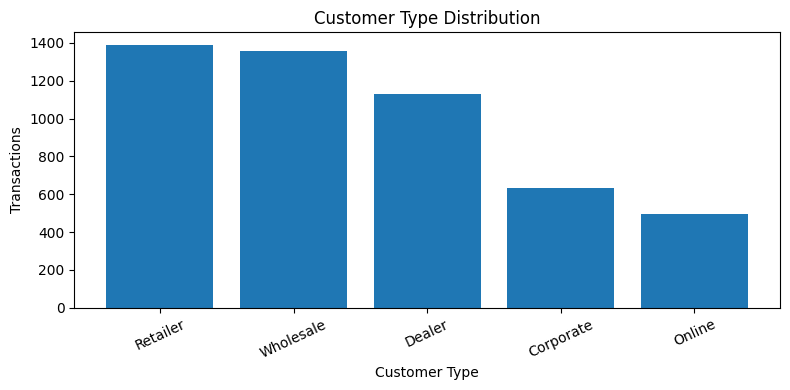

In [5]:
counts=df['Customer Type'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.bar(counts.index, counts.values)
plt.title('Customer Type Distribution')
plt.xlabel('Customer Type'); plt.ylabel('Transactions')
plt.xticks(rotation=25)
plt.tight_layout(); plt.show()

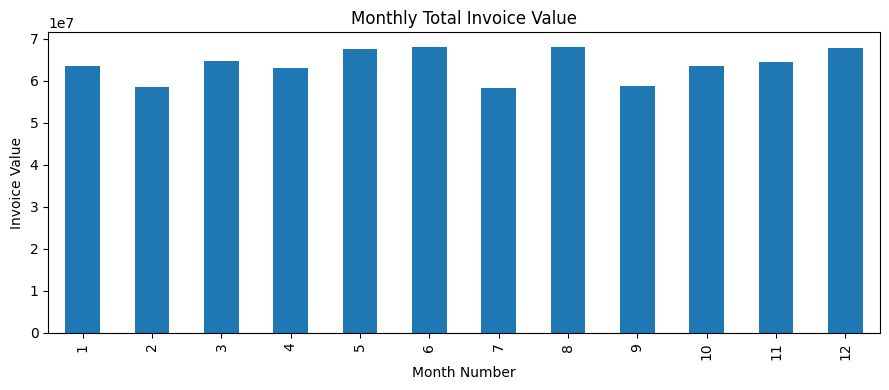

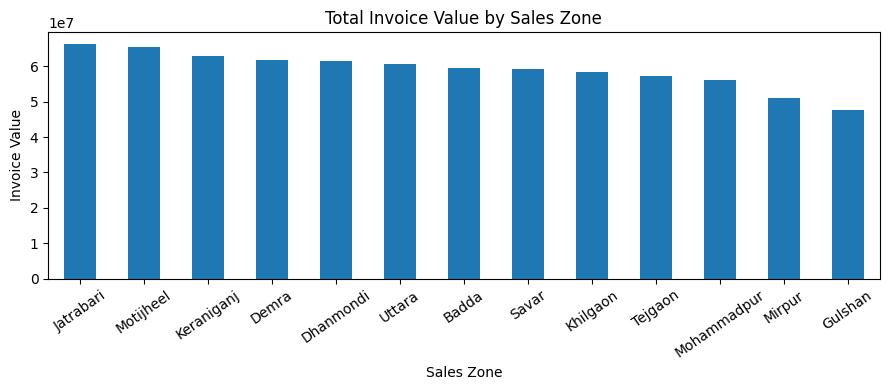

In [6]:
monthly = df.groupby('Month_Num')['Invoice Value'].sum()
plt.figure(figsize=(9,4))
monthly.plot(kind='bar')
plt.title('Monthly Total Invoice Value')
plt.xlabel('Month Number')
plt.ylabel('Invoice Value')
plt.tight_layout()
plt.show()

zone = df.groupby('Sales Zone')['Invoice Value'].sum().sort_values(ascending=False)
plt.figure(figsize=(9,4))
zone.plot(kind='bar')
plt.title('Total Invoice Value by Sales Zone')
plt.ylabel('Invoice Value')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

### Distribution of numeric sales columns

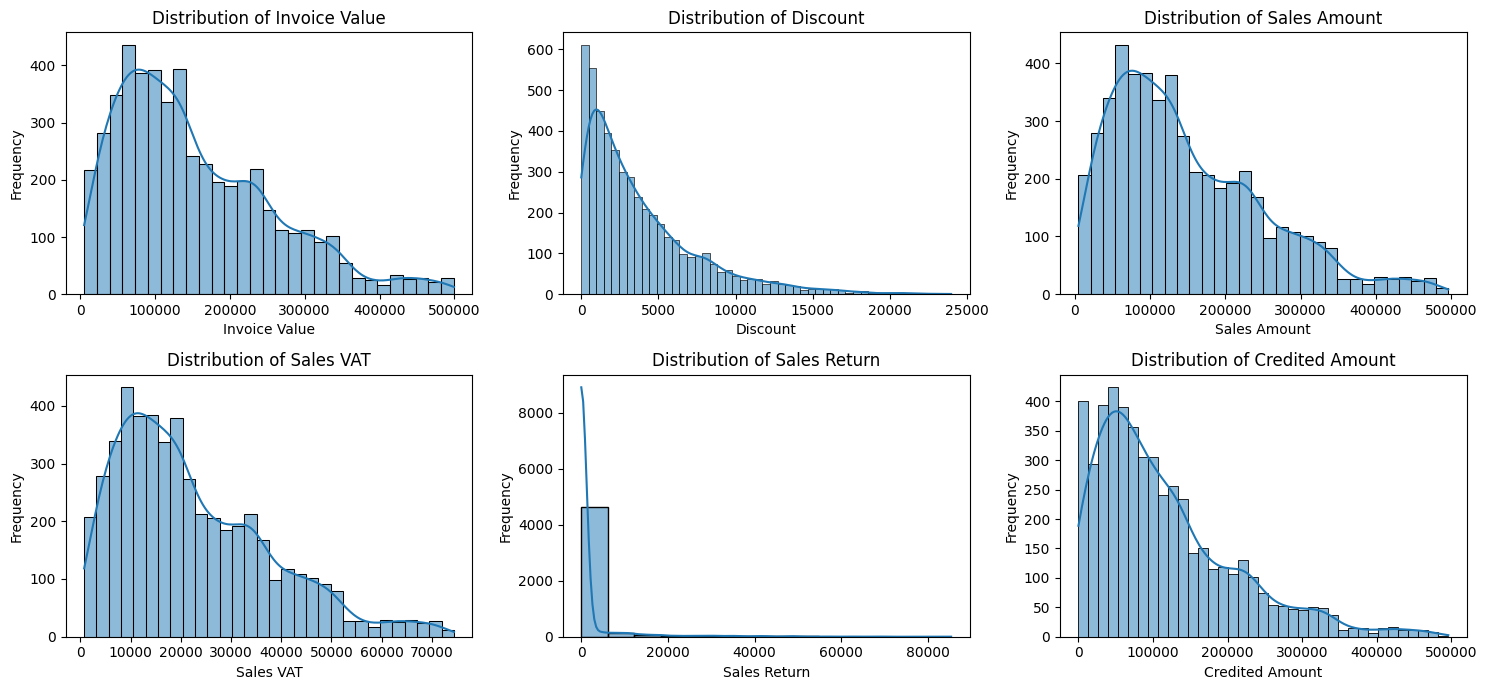

In [7]:
num_cols = [
    "Invoice Value",
    "Discount",
    "Sales Amount",
    "Sales VAT",
    "Sales Return",
    "Credited Amount"
]

ncols = 3
nrows = int(np.ceil(len(num_cols) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5 * ncols, 3.5 * nrows)
)

axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, num_cols):
    sns.histplot(
        df[col].dropna(),
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

# Hide unused plots
for ax in axes[len(num_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

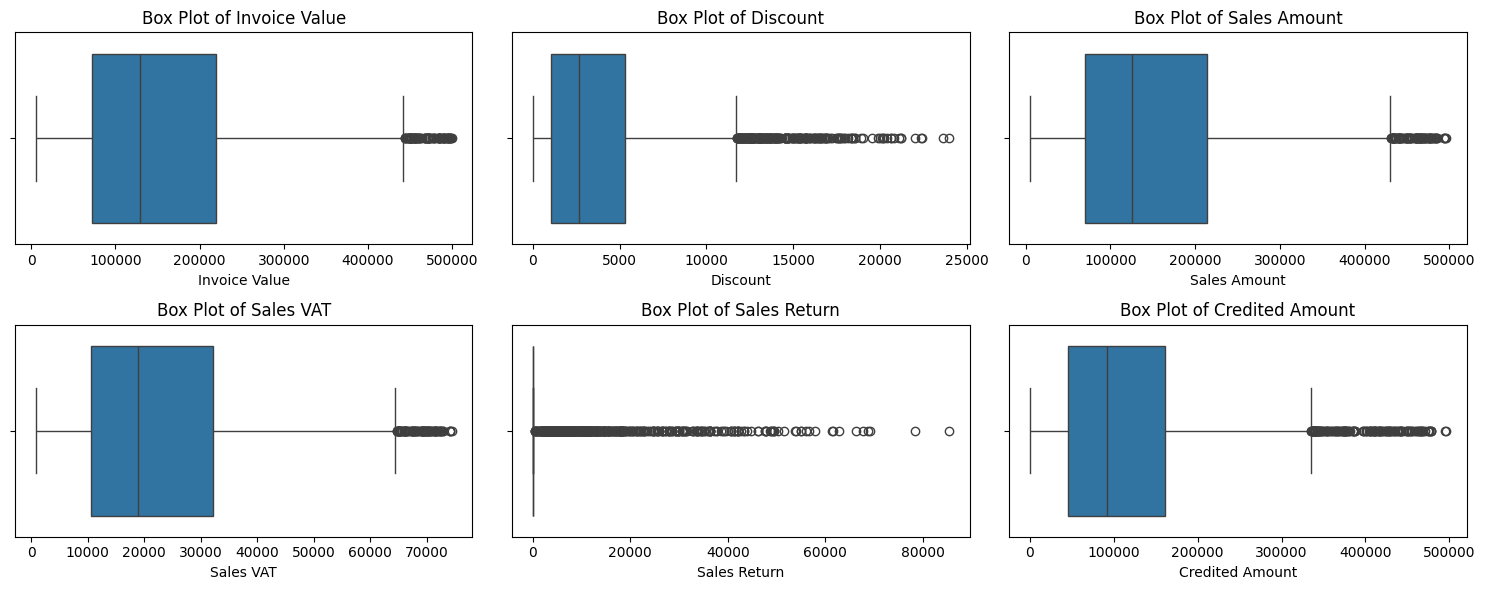

In [8]:
# Box plots to identify outliers in sales-related numerical variables

num_cols = [
    "Invoice Value",
    "Discount",
    "Sales Amount",
    "Sales VAT",
    "Sales Return",
    "Credited Amount"
]

ncols = 3
nrows = int(np.ceil(len(num_cols) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5 * ncols, 3 * nrows)
)

axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, num_cols):
    sns.boxplot(
        x=df[col].dropna(),
        ax=ax
    )
    ax.set_title(f"Box Plot of {col}")
    ax.set_xlabel(col)

# Hide unused plots
for ax in axes[len(num_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

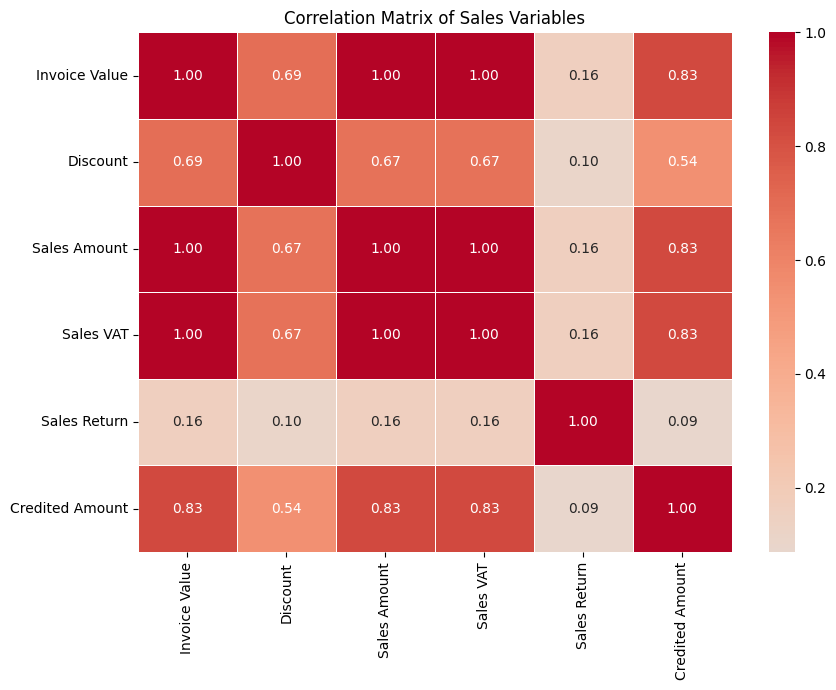

In [9]:
# Correlation between sales-related numerical columns

num_cols = [
    "Invoice Value",
    "Discount",
    "Sales Amount",
    "Sales VAT",
    "Sales Return",
    "Credited Amount"
]

plt.figure(figsize=(9, 7))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Sales Variables")
plt.tight_layout()
plt.show()

In [10]:
summary = df.groupby('Customer Type').agg(
    Transactions=('Transaction ID','count'),
    Total_Invoice_Value=('Invoice Value','sum'),
    Avg_Invoice_Value=('Invoice Value','mean'),
    Total_Return=('Sales Return','sum'),
    Total_Credited=('Credited Amount','sum')
).sort_values('Total_Invoice_Value', ascending=False)
summary.round(2)

,Transactions,Total_Invoice_Value,Avg_Invoice_Value,Total_Return,Total_Credited
Customer Type,,,,,
Wholesale,1355,276486000,204048.71,2991723.93,2.068680e+08
Corporate,634,188800000,297791.80,2081059.73,1.400011e+08
Dealer,1132,165780700,146449.38,1529910.11,1.252200e+08
Retailer,1386,110683300,79858.08,1173893.33,8.507571e+07
Online,493,25352100,51424.14,358158.70,1.856269e+07


## 6. Preprocessing Pipeline

Numeric features are median-imputed and standardized. Categorical features are most-frequent imputed and one-hot encoded. Pipelines ensure preprocessing is learned from the training data rather than the test data.

In [11]:
def make_preprocessor(X):
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    numeric = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    categorical = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    prep = ColumnTransformer([
        ('num', numeric, num_cols),
        ('cat', categorical, cat_cols)
    ])
    return prep, num_cols, cat_cols

# 7. Supervised Learning — Classification
### Target: Customer Type

In [12]:
classification_drop = id_cols + ['Customer Type', 'Credited Amount']
X_cls = df.drop(columns=classification_drop)
y_cls = df['Customer Type']

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=42, stratify=y_cls
)

preprocessor, num_cols, cat_cols = make_preprocessor(X_cls)
print('Training rows:', len(X_train), 'Testing rows:', len(X_test))

Training rows: 4000 Testing rows: 1000


In [13]:
def evaluate_classifier(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    result = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, pred, average='weighted', zero_division=0),
        'F1': f1_score(y_test, pred, average='weighted', zero_division=0)
    }
    print(name)
    print(pd.Series({k:v for k,v in result.items() if k != 'Model'}))
    print(classification_report(y_test, pred, zero_division=0))
    return result, model, pred

models = [
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('Decision Tree', DecisionTreeClassifier(max_depth=8, min_samples_split=10, min_samples_leaf=5, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)),
    ('Naive Bayes', GaussianNB()),
    ('SVM', SVC(kernel='rbf', C=1.0, random_state=42)),
    ('Neural Network', MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42))
]

classification_results=[]
fitted_models={}
predictions={}
for name, estimator in models:
    pipe=Pipeline([('prep', preprocessor), ('model', estimator)])
    res, fitted, pred = evaluate_classifier(pipe, name)
    classification_results.append(res)
    fitted_models[name]=fitted
    predictions[name]=pred

classification_comparison=pd.DataFrame(classification_results).sort_values('F1', ascending=False)
classification_comparison

KNN
Accuracy     0.408000
Precision    0.409874
Recall       0.408000
F1           0.405665
dtype: float64
              precision    recall  f1-score   support

   Corporate       0.49      0.43      0.46       127
      Dealer       0.35      0.41      0.38       226
      Online       0.19      0.15      0.17        99
    Retailer       0.43      0.51      0.47       277
   Wholesale       0.48      0.39      0.43       271

    accuracy                           0.41      1000
   macro avg       0.39      0.38      0.38      1000
weighted avg       0.41      0.41      0.41      1000

Decision Tree
Accuracy     0.506000
Precision    0.519333
Recall       0.506000
F1           0.479343
dtype: float64
              precision    recall  f1-score   support

   Corporate       0.83      0.43      0.57       127
      Dealer       0.42      0.43      0.43       226
      Online       0.27      0.07      0.11        99
    Retailer       0.49      0.87      0.62       277
   Wholesale    

,Model,Accuracy,Precision,Recall,F1
1,Decision Tree,0.506,0.519333,0.506,0.479343
2,Random Forest,0.505,0.529234,0.505,0.474129
4,SVM,0.515,0.499131,0.515,0.468991
0,KNN,0.408,0.409874,0.408,0.405665
3,Naive Bayes,0.387,0.417877,0.387,0.392442
5,Neural Network,0.384,0.387548,0.384,0.385358


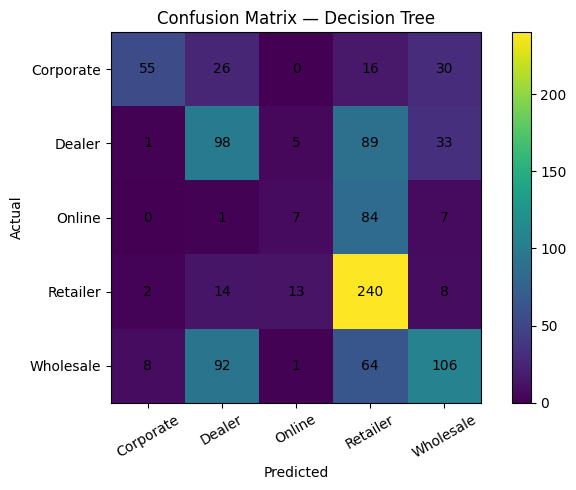

Best classification model: Decision Tree


In [14]:
best_cls_name = classification_comparison.iloc[0]['Model']
best_pred = predictions[best_cls_name]
cm = confusion_matrix(y_test, best_pred, labels=sorted(y_cls.unique()))
plt.figure(figsize=(7,5))
plt.imshow(cm, interpolation='nearest')
plt.title(f'Confusion Matrix — {best_cls_name}')
plt.colorbar()
classes=sorted(y_cls.unique())
plt.xticks(range(len(classes)), classes, rotation=30)
plt.yticks(range(len(classes)), classes)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()
print('Best classification model:', best_cls_name)

### Cross-validation for the selected classification baseline

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_pipeline = fitted_models[best_cls_name]
cv_f1 = cross_val_score(best_pipeline, X_cls, y_cls, cv=cv, scoring='f1_weighted', n_jobs=-1)
print('5-fold weighted F1 scores:', np.round(cv_f1,4))
print('Mean CV weighted F1:', round(cv_f1.mean(),4))

5-fold weighted F1 scores: [0.4696 0.4864 0.4447 0.4874 0.4799]
Mean CV weighted F1: 0.4736


## 8. Supervised Learning — Regression
### Target: Credited Amount

The target is `Credited Amount`. To reduce direct leakage, `Sales Amount` and `Sales VAT` are not used as predictors. Identifier and free-text columns are also excluded.

In [16]:
regression_drop = id_cols + ['Customer Type', 'Credited Amount', 'Sales Amount', 'Sales VAT']
X_reg = df.drop(columns=regression_drop)
y_reg = df['Credited Amount']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

reg_prep, _, _ = make_preprocessor(X_reg)

def evaluate_regressor(model, name):
    model.fit(Xr_train, yr_train)
    pred = model.predict(Xr_test)
    result = {
        'Model': name,
        'MAE': mean_absolute_error(yr_test, pred),
        'RMSE': mean_squared_error(yr_test, pred) ** 0.5,
        'R2': r2_score(yr_test, pred)
    }
    print(name, result)
    return result, model, pred

reg_models=[
    ('Linear Regression', LinearRegression()),
    ('Decision Tree Regressor', DecisionTreeRegressor(max_depth=8, random_state=42)),
    ('Random Forest Regressor', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
]
regression_results=[]; reg_fitted={}; reg_predictions={}
for name, estimator in reg_models:
    pipe=Pipeline([('prep', reg_prep), ('model', estimator)])
    res, fitted, pred=evaluate_regressor(pipe,name)
    regression_results.append(res); reg_fitted[name]=fitted; reg_predictions[name]=pred

regression_comparison=pd.DataFrame(regression_results).sort_values('RMSE')
regression_comparison

Linear Regression {'Model': 'Linear Regression', 'MAE': 34376.02694418909, 'RMSE': 49940.91668108197, 'R2': 0.6991068254456039}
Decision Tree Regressor {'Model': 'Decision Tree Regressor', 'MAE': 38323.53353164895, 'RMSE': 60273.0286650273, 'R2': 0.5617263640228858}
Random Forest Regressor {'Model': 'Random Forest Regressor', 'MAE': 36428.532376849995, 'RMSE': 54326.665015397084, 'R2': 0.6439381794743297}


,Model,MAE,RMSE,R2
0,Linear Regression,34376.026944,49940.916681,0.699107
2,Random Forest Regressor,36428.532377,54326.665015,0.643938
1,Decision Tree Regressor,38323.533532,60273.028665,0.561726


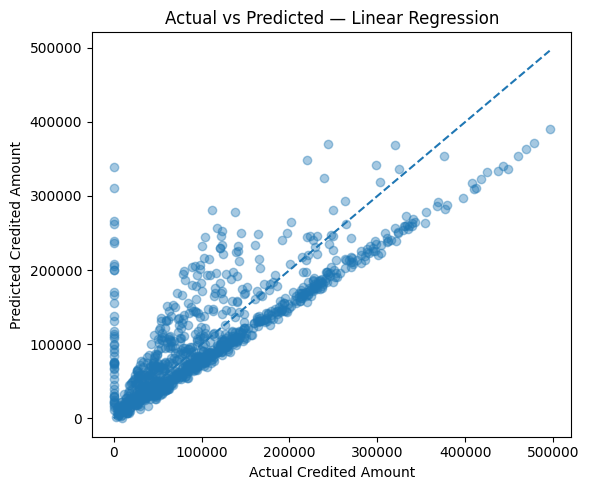

Best regression model: Linear Regression


In [17]:
best_reg_name = regression_comparison.iloc[0]['Model']
yhat = reg_predictions[best_reg_name]
plt.figure(figsize=(6,5))
plt.scatter(yr_test, yhat, alpha=0.4)
lims=[min(yr_test.min(), yhat.min()), max(yr_test.max(), yhat.max())]
plt.plot(lims, lims, '--')
plt.xlabel('Actual Credited Amount')
plt.ylabel('Predicted Credited Amount')
plt.title(f'Actual vs Predicted — {best_reg_name}')
plt.tight_layout()
plt.show()
print('Best regression model:', best_reg_name)

## 9. Unsupervised Learning — Customer Segmentation

Transactions are aggregated at customer level. KMeans is tested for several values of K using inertia and silhouette score. PCA is used only to visualize the final clusters.

In [18]:
customer = df.groupby('Customer Name').agg(
    Total_Invoice_Value=('Invoice Value','sum'),
    Avg_Invoice_Value=('Invoice Value','mean'),
    Total_Discount=('Discount','sum'),
    Total_Sales_Return=('Sales Return','sum'),
    Total_Credited=('Credited Amount','sum'),
    Transaction_Count=('Invoice No','count'),
    Avg_Credited=('Credited Amount','mean')
).reset_index()

cluster_features = customer.drop(columns=['Customer Name'])
cluster_scaled = StandardScaler().fit_transform(cluster_features)

ks=range(2,9); inertias=[]; silhouettes=[]
for k in ks:
    km=KMeans(n_clusters=k, n_init=10, random_state=42)
    labels=km.fit_predict(cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(cluster_scaled, labels))

scores=pd.DataFrame({'K':list(ks),'Inertia':inertias,'Silhouette':silhouettes})
scores

,K,Inertia,Silhouette
0,2,1150.257407,0.322856
1,3,968.365793,0.225666
2,4,821.078211,0.237774
3,5,732.623025,0.232519
4,6,659.228251,0.207213
5,7,599.123120,0.207078
6,8,543.885197,0.222071


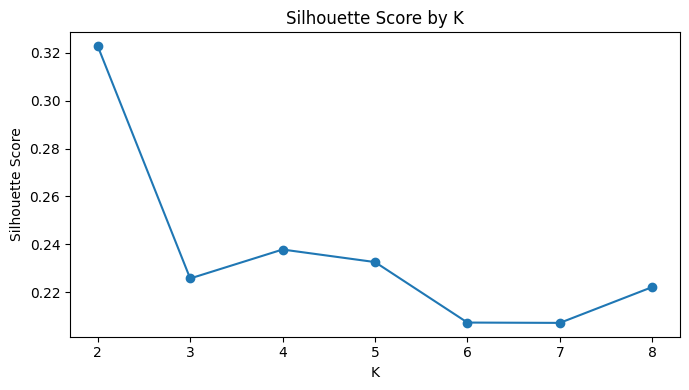

Selected K: 2
Final silhouette: 0.3229


In [19]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(scores['K'], scores['Silhouette'], marker='o')
ax.set_title('Silhouette Score by K')
ax.set_xlabel('K'); ax.set_ylabel('Silhouette Score')
plt.tight_layout(); plt.show()

best_k=int(scores.loc[scores['Silhouette'].idxmax(),'K'])
km=KMeans(n_clusters=best_k, n_init=10, random_state=42)
customer['Cluster']=km.fit_predict(cluster_scaled)
print('Selected K:', best_k)
print('Final silhouette:', round(silhouette_score(cluster_scaled, customer['Cluster']),4))

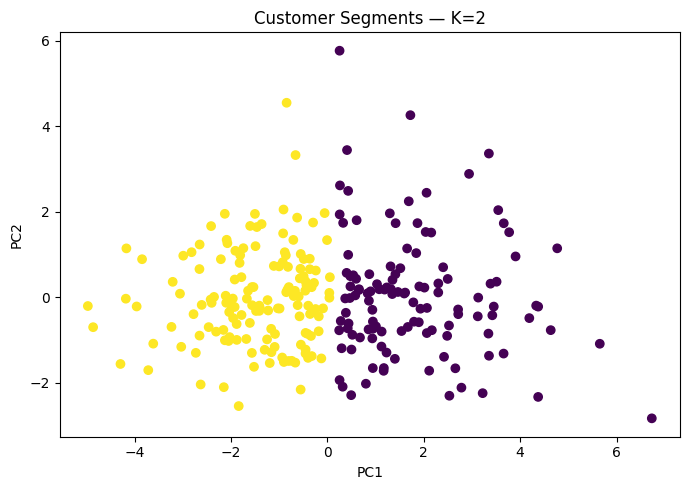

,Customers,Total_Invoice_Value,Avg_Invoice_Value,Total_Discount,Total_Sales_Return,Total_Credited,Transaction_Count,Avg_Credited
Cluster,,,,,,,,
0,119,3599127.73,167728.37,91837.03,37826.69,2754048.01,21.76,128764.59
1,145,2336592.41,142266.36,55977.21,25057.72,1710315.66,16.62,104005.34


In [20]:
pca=PCA(n_components=2, random_state=42)
coords=pca.fit_transform(cluster_scaled)
plt.figure(figsize=(7,5))
plt.scatter(coords[:,0], coords[:,1], c=customer['Cluster'])
plt.title(f'Customer Segments — K={best_k}')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout(); plt.show()

cluster_profile=customer.groupby('Cluster')[cluster_features.columns].mean().round(2)
cluster_sizes=customer['Cluster'].value_counts().sort_index().rename('Customers')
cluster_profile.insert(0,'Customers',cluster_sizes)
cluster_profile

## 10. Key Findings

Use the generated comparison tables and cluster profile above to write the final findings. The final report should identify the best classification model using weighted F1/accuracy, the best regression model using RMSE/MAE/R², and explain the measurable characteristics of each customer segment.

Do not describe a cluster as "good" or "bad". Describe it using measurable characteristics such as transaction count, average invoice value, returns, discounts, and credited amount.

## 11. Limitations

This project is based on approximately 2,200 cleaned sales transaction records from my practical work experience at Welburg Metal, where I was involved in sales and account-related activities and handled information related to customers and sales executives. The dataset represents actual business transaction information that I worked with; however, the data has been cleaned, prepared, and adapted for academic machine learning purposes. Due to business confidentiality and privacy considerations, sensitive information has not been disclosed.

The main limitations of the project are:

1. **Limited Dataset Size:** The dataset contains approximately 2,200 usable transaction records. Although these records represent actual sales activities, a larger dataset covering multiple years would provide more reliable and generalizable machine learning results.

2. **Data Privacy and Confidentiality:** Customer names, transaction identifiers, and other sensitive business information cannot be fully disclosed or used publicly. Therefore, some fields have been anonymized, removed, or transformed before being used in the university project.

3. **Data Cleaning and Preparation:** The original business data required cleaning and preparation before machine learning analysis. Missing values, inconsistent entries, duplicate records, and formatting issues may affect the final results.

4. **Customer and Executive Information:** The dataset contains customer and sales-executive information that can be useful for understanding sales behavior and performance. However, these variables should be used carefully because individual customer or employee performance should not be interpreted as a definitive business judgment.

5. **Unequal Class Distribution:** Customer Type categories may have different numbers of transactions. Therefore, accuracy alone may not provide a complete evaluation of classification performance. Precision, recall, F1-score, and confusion matrices should also be considered.

6. **Limited Business Features:** The available transaction data does not contain all possible factors that influence sales. Product-level information, quantity, inventory, delivery time, customer purchase history, payment delays, and seasonal factors could improve future models.

7. **Free-Text Information:** The Remarks field contains useful business information such as customer behavior, order type, payment status, and special instructions. In the current project, this text is not fully analyzed using Natural Language Processing (NLP).

8. **Model Scope:** The project focuses on selected classification, regression, and clustering algorithms. More advanced hyperparameter optimization and ensemble techniques could potentially improve the results.

9. **Academic Rather Than Production Use:** The models developed in this project are intended for academic analysis and demonstration. They should not be directly used for operational business decisions without additional validation, security checks, business approval, and testing on future data.

---

## 12. Future Work

The practical experience gained from handling Welburg sales and account-related data provides several opportunities for extending this machine learning project:

1. **Expand the Dataset:** Collect additional historical sales records from previous and future periods to create a larger and more representative dataset.

2. **Develop a Real Sales Prediction System:** Use historical sales transactions to develop models for predicting future sales amounts, monthly sales trends, and customer purchasing behavior.

3. **Customer Segmentation:** Apply K-Means and other clustering techniques to identify high-value, regular, new, and potentially inactive customers based on their transaction history.

4. **Sales Executive Analysis:** Develop analytical models to understand sales patterns across executives, zones, customer types, and sales channels without using the model as the sole basis for employee evaluation.

5. **Add Business Features:** Include product, quantity, order frequency, customer purchase history, payment delay, return history, discount percentage, and seasonal information where ethically and practically available.

6. **Improve Model Performance:** Apply `GridSearchCV`, `RandomizedSearchCV`, feature selection, and other optimization techniques to improve the performance of the selected models.

7. **Time-Aware Validation:** Use time-based train-test validation for future sales forecasting because sales data is naturally ordered by date.

8. **NLP for Remarks:** Analyze the `Remarks` field using Natural Language Processing (NLP) to identify patterns such as new customers, repeat customers, online orders, partial payments, special discounts, and other business activities.

9. **Develop a Sales Management Dashboard:** Build a dashboard using Python, Streamlit, Power BI, or another suitable platform to display sales trends, customer segments, executive performance indicators, and machine learning predictions.

10. **Deploy the Model for Business Support:** After sufficient testing and validation, the best-performing model could be integrated into a sales analytics system to support customer segmentation, sales forecasting, and management decision-making.

## 13. Conclusion

This project demonstrates a complete machine-learning workflow on the Welburg 2025 sales dataset. It includes data understanding, cleaning, feature engineering, exploratory analysis, preprocessing pipelines, classification, regression, customer segmentation, model comparison and interpretation. The final model choices should be based on the actual evaluation tables generated by this notebook rather than assumed performance.